In [1]:
from ultralytics import YOLO
import time

In [2]:
import torch

print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    num_devs = torch.cuda.device_count()
    print(f"Number of GPUs: {num_devs}")
    dev_num = torch.cuda.current_device()
    gpu_type = torch.cuda.get_device_name(dev_num)
    print(f"Current GPU: {gpu_type}")
else:
    print("No GPU found, using CPU")

CUDA available: True
Number of GPUs: 4
Current GPU: NVIDIA L40S


In [3]:
# Image folder
subset_folder = "./yolo-test/frames"

# Load the MBARI 315k model
# mbari_model = YOLO("./yolo-test/mbari_315k_yolov8.pt")

# Load default model
mbari_model = YOLO()

mbari_model.info()

YOLO26n summary: 260 layers, 2,572,280 parameters, 0 gradients, 6.1 GFLOPs


(260, 2572280, 0, 6.1192448)

In [4]:
%%time
t0 = time.perf_counter()

# Run inference on the sampled frames with MBARI 315k
results = mbari_model.predict(
    source = subset_folder,
    conf = 0.10,
    iou = 0.5,
    imgsz = 1024,
    device = 'cuda', # cuda:0 or cpu
    # batch = 3,
    agnostic_nms = True,
    save = True,
    save_txt = True,
    save_conf = True,
)
t1 = time.perf_counter() - t0
print(f"GPU Processing Time: {t1:.4f}s")

image 1/25 /home/jovyan/yolo-test/frames/frame_0.jpg: 768x1024 1 frisbee, 72.3ms


image 2/25 /home/jovyan/yolo-test/frames/frame_11436.jpg: 768x1024 (no detections), 5.8ms


image 3/25 /home/jovyan/yolo-test/frames/frame_14295.jpg: 768x1024 1 surfboard, 5.1ms


image 4/25 /home/jovyan/yolo-test/frames/frame_17154.jpg: 768x1024 1 frisbee, 4.9ms


image 5/25 /home/jovyan/yolo-test/frames/frame_20013.jpg: 768x1024 4 persons, 4.9ms


...

image 24/25 /home/jovyan/yolo-test/frames/frame_68616.jpg: 768x1024 (no detections), 4.9ms


image 25/25 /home/jovyan/yolo-test/frames/frame_8577.jpg: 768x1024 1 surfboard, 4.9ms


Speed: 2.1ms preprocess, 7.6ms inference, 0.6ms postprocess per image at shape (1, 3, 768, 1024)


Results saved to /home/jovyan/runs/detect/predict-13
17 labels saved to /home/jovyan/runs/detect/predict-13/labels


GPU Processing Time: 1.1514s
CPU times: user 707 ms, sys: 302 ms, total: 1.01 s
Wall time: 1.15 s


/home/jovyan/yolo-test/frames/frame_40026.jpg


name,class,confidence,box
str,i64,f64,struct[4]
"""surfboard""",37,0.28057,"{968.28442,669.47583,1023.79358,717.45618}"
"""person""",0,0.13026,"{265.2807,753.16437,280.98767,767.71265}"


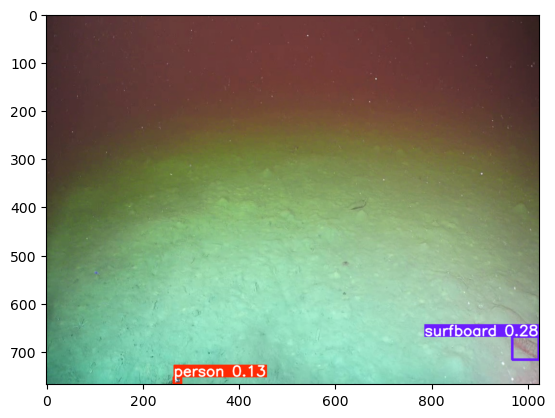

In [5]:
import matplotlib.pyplot as plt

# Example prediction results
selected_id = 12

print(results[selected_id].path)
plt.imshow(results[selected_id].plot())
results[selected_id].to_df()


/home/jovyan/yolo-test/frames/frame_60039.jpg


name,class,confidence,box
str,i64,f64,struct[4]
"""surfboard""",37,0.23095,"{0.29994,712.34094,30.00211,760.35828}"
"""sports ball""",32,0.22237,"{956.16748,526.48676,972.70453,547.77594}"


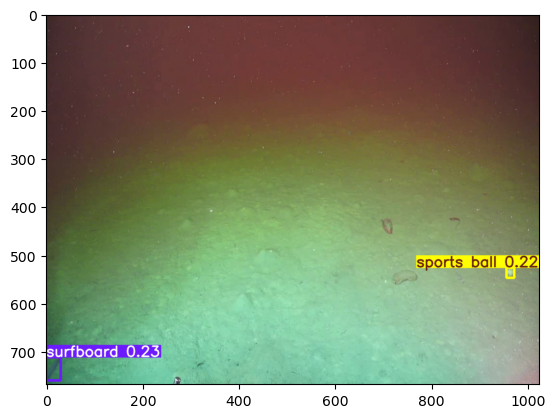

In [6]:
import matplotlib.pyplot as plt

# Example prediction results
selected_id = 20

print(results[selected_id].path)
plt.imshow(results[selected_id].plot())
results[selected_id].to_df()


In [7]:
import pandas as pd

# Concatenate all results
rows = []
for result in results: 
    image_path = result.path
    boxes = result.boxes
    if boxes is None or len(boxes) == 0:
        continue
    for i in range(len(boxes)):
        cls_id = int(boxes.cls[i])
        rows.append({
            "image": image_path,
            "class_id": cls_id,
            "class_name": result.names[cls_id],
            "confidence": float(boxes.conf[i]),
            "x1": float(boxes.xyxy[i][0]),
            "y1": float(boxes.xyxy[i][1]),
            "x2": float(boxes.xyxy[i][2]),
            "y2": float(boxes.xyxy[i][3]),
            "width": float(boxes.xywh[i][2]),
            "height": float(boxes.xywh[i][3]),
        })

df = pd.DataFrame(rows)

In [8]:
df

,image,class_id,class_name,confidence,x1,y1,x2,y2,width,height
0,/home/jovyan/yolo-test/frames/frame_0.jpg,29,frisbee,0.714216,511.170593,689.730591,561.180786,741.636169,50.010193,51.905579
1,/home/jovyan/yolo-test/frames/frame_14295.jpg,37,surfboard,0.155504,467.392944,633.557861,508.393250,700.078918,41.000305,66.521057
2,/home/jovyan/yolo-test/frames/frame_17154.jpg,29,frisbee,0.149934,371.638580,616.154053,389.461578,680.791138,17.822998,64.637085
3,/home/jovyan/yolo-test/frames/frame_20013.jpg,0,person,0.511757,967.554688,332.245483,1023.971497,496.798767,56.416809,164.553284
4,/home/jovyan/yolo-test/frames/frame_20013.jpg,0,person,0.301705,982.832703,462.658264,1023.704407,496.126038,40.871704,33.467773
5,/home/jovyan/yolo-test/frames/frame_20013.jpg,0,person,0.290348,967.358887,331.340576,1023.712097,364.150177,56.353210,32.809601
6,/home/jovyan/yolo-test/frames/frame_20013.jpg,0,person,0.103926,263.598755,753.126038,279.687500,767.699158,16.088745,14.573120
7,/home/jovyan/yolo-test/frames/frame_25731.jpg,14,bird,0.718791,29.802345,403.780914,128.391556,487.633148,98.589211,83.852234
8,/home/jovyan/yolo-test/frames/frame_2859.jpg,29,frisbee,0.585691,580.563843,583.607361,625.979736,609.545349,45.415894,25.937988
9,/home/jovyan/yolo-test/frames/frame_28590.jpg,0,person,0.102499,264.162079,753.434998,279.488739,767.716003,15.326660,14.281006


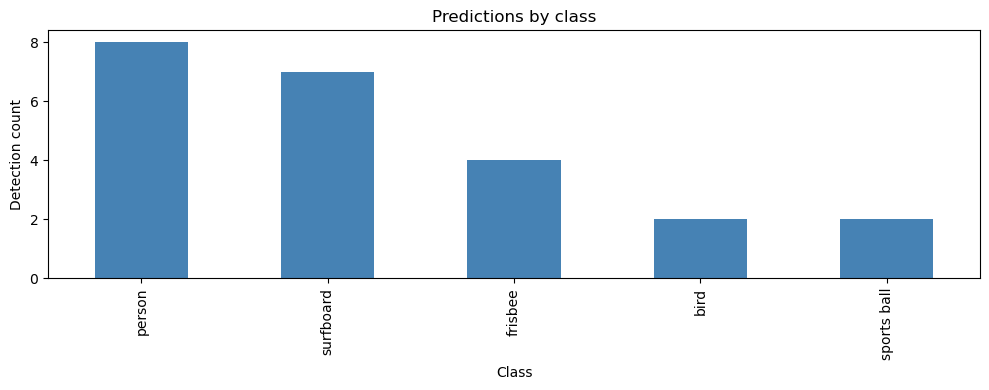

In [9]:
import matplotlib.pyplot as plt

counts = df["class_name"].value_counts().sort_values(ascending=False)

ax = counts.plot(kind="bar", figsize=(10, 4), color="steelblue")
ax.set_xlabel("Class")
ax.set_ylabel("Detection count")
ax.set_title("Predictions by class")
plt.tight_layout()
plt.show()

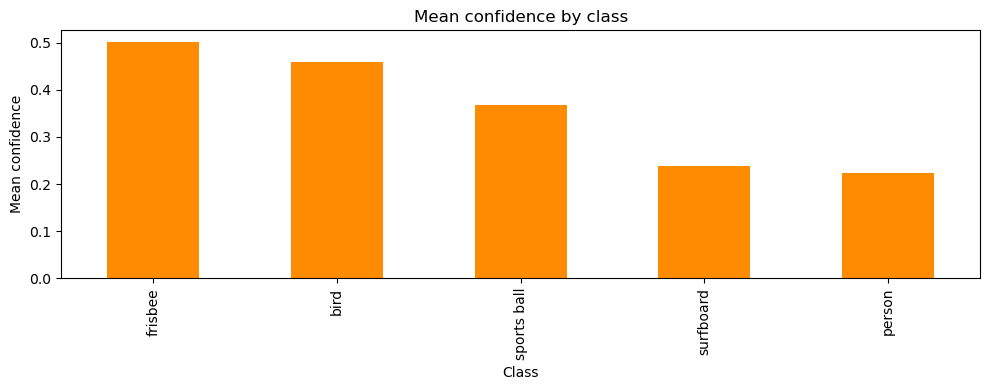

In [10]:
avg_conf = df.groupby("class_name")["confidence"].mean().sort_values(ascending=False)

ax = avg_conf.plot(kind="bar", figsize=(10, 4), color="darkorange")
ax.set_xlabel("Class")
ax.set_ylabel("Mean confidence")
ax.set_title("Mean confidence by class")
plt.tight_layout()
plt.show()

In [11]:
from pathlib import Path

rows = []

for result in results:
    image_name = Path(result.path).name if getattr(result, 'path', None) else 'unknown'
    boxes = result.boxes

    if boxes is None or len(boxes) == 0:
        continue

    for i in range(len(boxes)):
        class_id = int(boxes.cls[i])
        rows.append({
            'image': image_name,
            'class_id': class_id,
            'class_name': result.names[class_id],
            'confidence': float(boxes.conf[i]),
            'x1': float(boxes.xyxy[i][0]),
            'y1': float(boxes.xyxy[i][1]),
            'x2': float(boxes.xyxy[i][2]),
            'y2': float(boxes.xyxy[i][3]),
        })

detection_df = pd.DataFrame(rows)

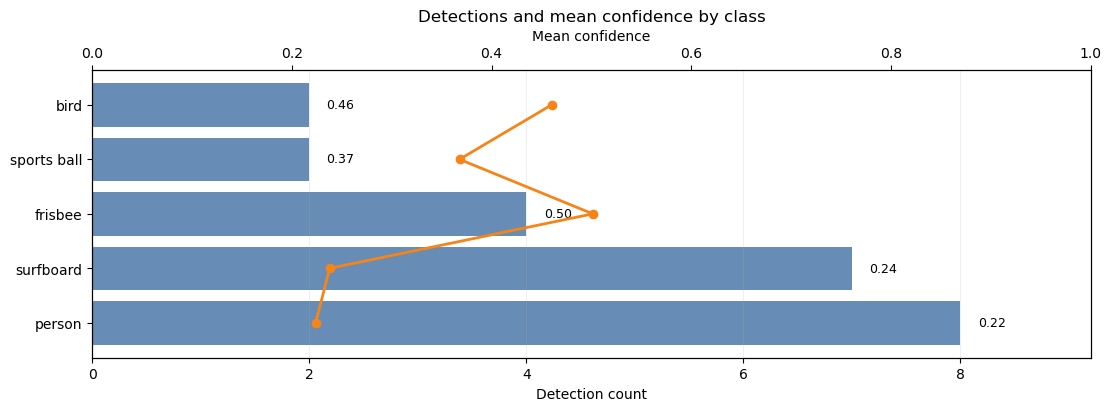

In [12]:
import numpy as np
summary = (
    df.groupby('class_name', as_index=False)
    .agg(
        detections=('class_name', 'size'),
        mean_confidence=('confidence', 'mean'),
    )
    .sort_values('detections', ascending=True)
)

fig, ax1 = plt.subplots(figsize=(11, max(4, 0.45 * len(summary))), constrained_layout=True)
y_pos = np.arange(len(summary))
bars = ax1.barh(y_pos, summary['detections'], color='#4C78A8', alpha=0.85)
ax1.set_yticks(y_pos)
ax1.set_yticklabels(summary['class_name'])
ax1.set_xlabel('Detection count')
ax1.set_title('Detections and mean confidence by class')
ax1.grid(axis='x', alpha=0.2)
ax1.invert_yaxis()

ax2 = ax1.twiny()
ax2.plot(summary['mean_confidence'], y_pos, color='#F58518', marker='o', linewidth=2)
ax2.set_xlabel('Mean confidence')
ax2.set_xlim(0, 1.0)
ax1.set_xlim(0, max(summary['detections']) * 1.15)

for bar, conf in zip(bars, summary['mean_confidence']):
    ax1.text(
        bar.get_width() + max(summary['detections']) * 0.02,
        bar.get_y() + bar.get_height() / 2,
        f'{conf:.2f}',
        va='center',
        fontsize=9,
    )

plt.show()

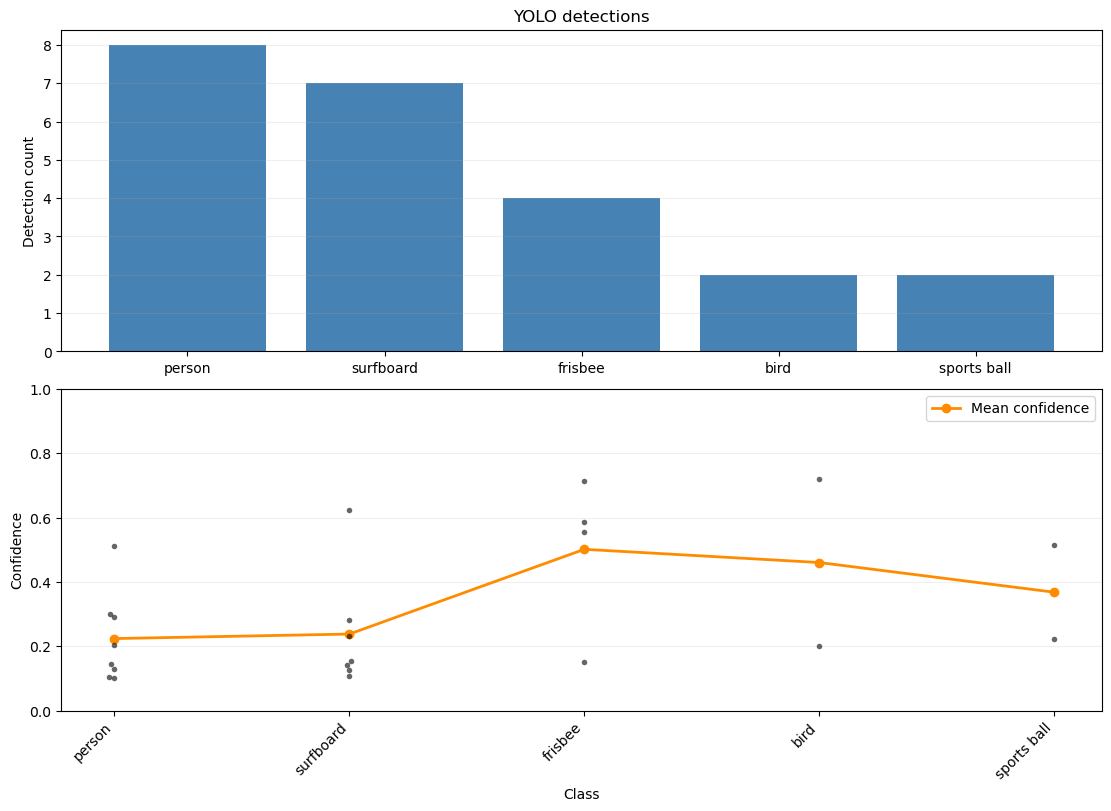

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# If needed:
# detection_df should have at least: class_name, confidence

detection_df = df 

class_order = (
    detection_df["class_name"]
    .value_counts()
    .index
    .tolist()
)

count_df = (
    detection_df["class_name"]
    .value_counts()
    .reindex(class_order)
    .reset_index()
)
count_df.columns = ["class_name", "count"]

mean_conf = (
    detection_df.groupby("class_name")["confidence"]
    .mean()
    .reindex(class_order)
)

fig, axes = plt.subplots(
    2, 1,
    figsize=(11, 8),
    sharex=False,
    constrained_layout=True
)

# Top: counts
axes[0].bar(count_df["class_name"], count_df["count"], color="steelblue")
axes[0].set_ylabel("Detection count")
axes[0].set_title("YOLO detections")
axes[0].grid(axis="y", alpha=0.2)

# Bottom: beeswarm of confidence
sns.swarmplot(
    data=detection_df,
    x="class_name",
    y="confidence",
    order=class_order,
    ax=axes[1],
    size=4,
    color="black",
    alpha=0.6,
)

# Mean confidence line/markers
axes[1].plot(
    class_order,
    mean_conf.values,
    color="darkorange",
    marker="o",
    linewidth=2,
    label="Mean confidence",
)

axes[1].set_ylabel("Confidence")
axes[1].set_xlabel("Class")
axes[1].set_ylim(0, 1)
axes[1].grid(axis="y", alpha=0.2)
axes[1].legend()

plt.xticks(rotation=45, ha="right")
plt.show()